<a href="https://colab.research.google.com/github/Akashsky123/Deep-Learning-Lab/blob/main/Experiment9_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 9: Generative Adversarial Networks (GANs)
## Vanilla GAN vs DCGAN on Fashion-MNIST

**No API keys required** — dataset downloaded via `torchvision`, no W&B or Hugging Face login needed.

| Item | Detail |
|------|--------|
| Dataset | Fashion-MNIST (torchvision, auto-download) |
| Architectures | Vanilla GAN, DCGAN |
| Loss functions | BCE, LSGAN, WGAN |
| Optimizers | Adam, RMSprop, SGD |
| Tracking | Local plots saved to `/content/` |

In [1]:
# All standard libraries — no API keys needed
import os, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : Tesla T4


In [2]:
# ── Download Fashion-MNIST automatically via torchvision ──────────────────────
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),   # light augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),      # maps [0,1] -> [-1,1]
])

full_train = torchvision.datasets.FashionMNIST(
    root='/content/data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.FashionMNIST(
    root='/content/data', train=False, download=True, transform=transform)

# 80 / 10 / 10  split on training set
n = len(full_train)
n_train, n_val = int(.8*n), int(.1*n)
n_test2 = n - n_train - n_val
train_ds, val_ds, _ = random_split(
    full_train, [n_train, n_val, n_test2],
    generator=torch.Generator().manual_seed(42))

BATCH = 128
train_loader = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train {n_train} | Val {n_val} | Test {len(test_ds)}')
print(f'Batches / epoch : {len(train_loader)}')

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.88MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 157kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]

Train 48000 | Val 6000 | Test 10000
Batches / epoch : 375


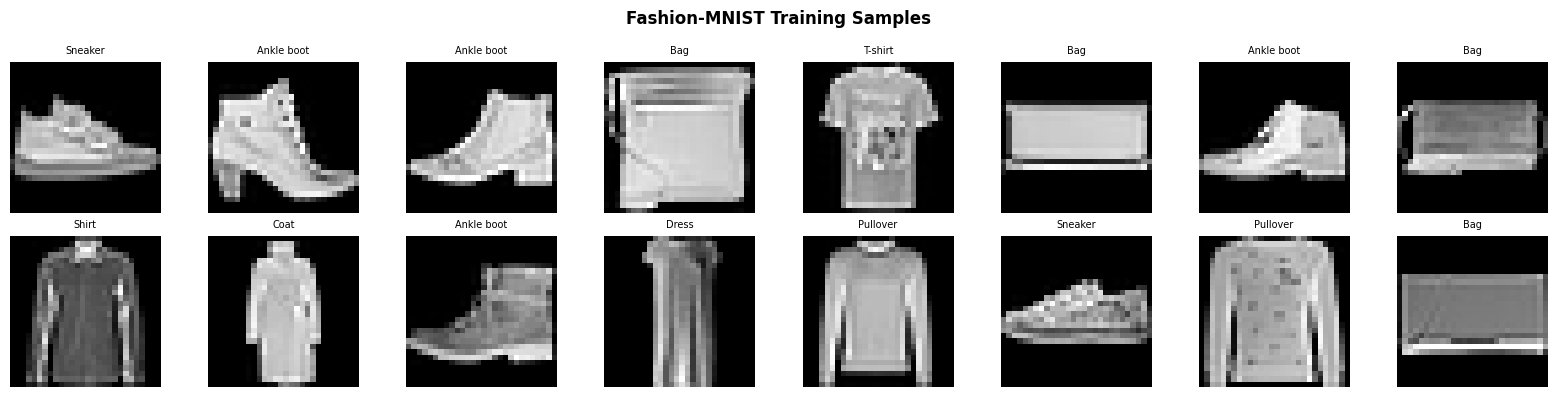

Saved: /content/sample_images.png


In [3]:
CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow((imgs[i].squeeze().numpy() + 1) / 2, cmap='gray')
    ax.set_title(CLASS_NAMES[lbls[i]], fontsize=7)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Training Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/sample_images.png')

## Model Architectures

- **Vanilla GAN** — fully-connected layers
- **DCGAN** — transposed convolutions + BatchNorm
- **WGAN Critic** — same as above but no Sigmoid (raw score)

In [4]:
# ── Vanilla GAN ────────────────────────────────────────────────────────────────
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),  nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256, 512),         nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 1024),        nn.LeakyReLU(0.2), nn.BatchNorm1d(1024),
            nn.Linear(1024, 28*28),      nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 1024), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(1024,  512),  nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512,   256),  nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256,   1),    nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


# ── DCGAN ──────────────────────────────────────────────────────────────────────
def weights_init(m):
    cn = m.__class__.__name__
    if 'Conv' in cn:      nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class DCGenerator(nn.Module):
    """Transposed-conv generator: z -> (1,28,28)"""
    def __init__(self, latent_dim=100, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.ngf4 = ngf * 4
        self.proj = nn.Sequential(
            nn.Linear(latent_dim, ngf*4*7*7), nn.ReLU(True))
        self.main = nn.Sequential(
            # (ngf*4, 7, 7) -> (ngf*2, 14, 14)
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            # (ngf*2, 14,14) -> (ngf, 28, 28)
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),   nn.ReLU(True),
            # (ngf, 28, 28) -> (1, 28, 28)
            nn.Conv2d(ngf, 1, 3, 1, 1, bias=False), nn.Tanh(),
        )
        self.apply(weights_init)
    def forward(self, z):
        x = self.proj(z).view(-1, self.ngf4, 7, 7)
        return self.main(x)


class DCDiscriminator(nn.Module):
    """Strided-conv discriminator: (1,28,28) -> scalar"""
    def __init__(self, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, ndf,    4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf*2,4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2,ndf*4,3,2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
        )
        self.clf = nn.Sequential(nn.Flatten(), nn.Linear(ndf*4*4*4, 1), nn.Sigmoid())
        self.apply(weights_init)
    def forward(self, x):
        return self.clf(self.main(x))


# ── WGAN Critic (no Sigmoid) ───────────────────────────────────────────────────
class WGANCritic(nn.Module):
    def __init__(self, arch='vanilla', ndf=64):
        super().__init__()
        self.is_conv = (arch == 'dcgan')
        if not self.is_conv:
            self.net = nn.Sequential(
                nn.Linear(784,1024), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                nn.Linear(1024,512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                nn.Linear(256,1),
            )
        else:
            self.main = nn.Sequential(
                nn.Conv2d(1, ndf,    4,2,1,bias=False), nn.LeakyReLU(0.2,True),
                nn.Conv2d(ndf,ndf*2, 4,2,1,bias=False), nn.InstanceNorm2d(ndf*2), nn.LeakyReLU(0.2,True),
                nn.Conv2d(ndf*2,ndf*4,3,2,1,bias=False),nn.InstanceNorm2d(ndf*4), nn.LeakyReLU(0.2,True),
            )
            self.clf = nn.Sequential(nn.Flatten(), nn.Linear(ndf*4*4*4,1))
            self.apply(weights_init)
    def forward(self, x):
        if not self.is_conv: return self.net(x.view(x.size(0),-1))
        return self.clf(self.main(x))


def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'VanillaGenerator : {count_params(VanillaGenerator()):,}')
print(f'DCGenerator      : {count_params(DCGenerator()):,}')
print(f'VanillaDisc      : {count_params(VanillaDiscriminator()):,}')
print(f'DCDiscriminator  : {count_params(DCDiscriminator()):,}')

VanillaGenerator : 1,489,936
DCGenerator      : 1,923,264
VanillaDisc      : 1,460,225
DCDiscriminator  : 431,873


## Loss Functions

| Loss | D objective | G objective |
|------|-------------|-------------|
| BCE | log D(x) + log(1-D(G(z))) | -log D(G(z)) |
| LSGAN | MSE to real=1, fake=0 | MSE to real=1 |
| WGAN | -E[D(x)] + E[D(G(z))] + weight clip | -E[D(G(z))] |

In [5]:
bce_fn = nn.BCELoss()
mse_fn = nn.MSELoss()

def disc_loss(D, real, fake, loss_type):
    bs, dev = real.size(0), real.device
    if loss_type == 'bce':
        return (bce_fn(D(real), torch.ones(bs,1,device=dev)) +
                bce_fn(D(fake.detach()), torch.zeros(bs,1,device=dev))) / 2
    if loss_type == 'lsgan':
        return (mse_fn(D(real), torch.ones(bs,1,device=dev)) +
                mse_fn(D(fake.detach()), torch.zeros(bs,1,device=dev))) / 2
    # wgan
    return -D(real).mean() + D(fake.detach()).mean()


def gen_loss(D, fake, loss_type):
    bs, dev = fake.size(0), fake.device
    if loss_type == 'bce':
        return bce_fn(D(fake), torch.ones(bs,1,device=dev))
    if loss_type == 'lsgan':
        return mse_fn(D(fake), torch.ones(bs,1,device=dev))
    return -D(fake).mean()


print('Loss functions ready!')

Loss functions ready!


In [6]:
def make_opt(name, params, lr):
    if name == 'adam':    return torch.optim.Adam(params, lr=lr, betas=(0.5, 0.999))
    if name == 'rmsprop': return torch.optim.RMSprop(params, lr=lr)
    return torch.optim.SGD(params, lr=lr, momentum=0.9)


def make_image_grid(G, latent_dim, n=64):
    """Generate n images and return as a single grid numpy array."""
    G.eval()
    with torch.no_grad():
        imgs = G(torch.randn(n, latent_dim, device=device)).cpu()
    G.train()
    grid = torchvision.utils.make_grid(imgs, nrow=8, normalize=True, value_range=(-1,1))
    return grid.permute(1,2,0).numpy()


def train_gan(
    arch='dcgan',
    loss_type='bce',
    optimizer_name='adam',
    latent_dim=100,
    n_epochs=30,
    lr=2e-4,
    wgan_clip=0.01,
    n_critic=5,
    log_every=5,
):
    run_name = f'{arch}_{loss_type}_{optimizer_name}'
    print(f'\nTraining: {run_name}')

    # --- Build models ---
    if arch == 'vanilla':
        G = VanillaGenerator(latent_dim).to(device)
        D = (WGANCritic('vanilla') if loss_type == 'wgan'
             else VanillaDiscriminator()).to(device)
    else:
        G = DCGenerator(latent_dim).to(device)
        D = (WGANCritic('dcgan') if loss_type == 'wgan'
             else DCDiscriminator()).to(device)

    opt_G = make_opt(optimizer_name, G.parameters(), lr)
    opt_D = make_opt(optimizer_name, D.parameters(), lr)

    g_hist, d_hist = [], []
    final_grid = None

    for epoch in range(1, n_epochs + 1):
        G.train(); D.train()
        gL = dL = 0.0

        for real, _ in train_loader:
            real = real.to(device)
            bs   = real.size(0)

            # Discriminator / Critic
            iters = n_critic if loss_type == 'wgan' else 1
            for _ in range(iters):
                z    = torch.randn(bs, latent_dim, device=device)
                fake = G(z).detach()
                opt_D.zero_grad()
                ld = disc_loss(D, real, fake, loss_type)
                ld.backward(); opt_D.step()
                if loss_type == 'wgan':
                    for p in D.parameters(): p.data.clamp_(-wgan_clip, wgan_clip)

            # Generator
            z    = torch.randn(bs, latent_dim, device=device)
            fake = G(z)
            opt_G.zero_grad()
            lg = gen_loss(D, fake, loss_type)
            lg.backward(); opt_G.step()

            gL += lg.item(); dL += ld.item()

        avg_g = gL / len(train_loader)
        avg_d = dL / len(train_loader)
        g_hist.append(avg_g); d_hist.append(avg_d)

        if epoch % log_every == 0 or epoch == 1:
            final_grid = make_image_grid(G, latent_dim)
            print(f'  [{epoch:3d}/{n_epochs}]  G={avg_g:.4f}  D={avg_d:.4f}')

    # Save trained generator
    save_path = f'/content/{run_name}_G.pth'
    torch.save(G.state_dict(), save_path)
    print(f'  Model saved -> {save_path}')

    # Final image grid
    final_grid = make_image_grid(G, latent_dim)
    return G, g_hist, d_hist, final_grid


print('Training function ready!')

Training function ready!


## Run All 9 Experiments

Set `N_EPOCHS = 5` for a quick smoke-test, `30` for the full experiment.

In [8]:
N_EPOCHS = 20   # change to 5 for quick test

EXPERIMENTS = [
    # Architecture comparison (BCE + Adam baseline)
    dict(arch='vanilla', loss_type='bce',   optimizer_name='adam'),
    dict(arch='dcgan',   loss_type='bce',   optimizer_name='adam'),
    # Loss function comparison (DCGAN + Adam)
    dict(arch='dcgan',   loss_type='lsgan', optimizer_name='adam'),
    dict(arch='dcgan',   loss_type='wgan',  optimizer_name='rmsprop'),
    # Optimizer comparison (DCGAN + BCE)
    dict(arch='dcgan',   loss_type='bce',   optimizer_name='rmsprop'),
    dict(arch='dcgan',   loss_type='bce',   optimizer_name='sgd'),
    # Vanilla with other losses
    dict(arch='vanilla', loss_type='lsgan', optimizer_name='adam'),
    dict(arch='vanilla', loss_type='wgan',  optimizer_name='rmsprop'),
    # Best combo
    dict(arch='dcgan',   loss_type='lsgan', optimizer_name='rmsprop'),
]

RESULTS = {}
for cfg in EXPERIMENTS:
    lr = 2e-4 if cfg['optimizer_name'] == 'adam' else 5e-5
    G, gl, dl, grid = train_gan(**cfg, latent_dim=100, n_epochs=N_EPOCHS,
                                 lr=lr, log_every=5)
    key = f"{cfg['arch']}_{cfg['loss_type']}_{cfg['optimizer_name']}"
    RESULTS[key] = dict(G=G, gl=gl, dl=dl, grid=grid)

print('\nAll experiments complete!')


Training: vanilla_bce_adam
  [  1/20]  G=2.2909  D=0.3154
  [  5/20]  G=1.0825  D=0.5804
  [ 10/20]  G=0.9220  D=0.6345
  [ 15/20]  G=0.8618  D=0.6524
  [ 20/20]  G=0.8245  D=0.6620
  Model saved -> /content/vanilla_bce_adam_G.pth

Training: dcgan_bce_adam
  [  1/20]  G=2.4342  D=0.2604
  [  5/20]  G=2.0127  D=0.2982
  [ 10/20]  G=2.1755  D=0.2605
  [ 15/20]  G=2.2939  D=0.2655
  [ 20/20]  G=2.3557  D=0.2553
  Model saved -> /content/dcgan_bce_adam_G.pth

Training: dcgan_lsgan_adam
  [  1/20]  G=0.6969  D=0.0801
  [  5/20]  G=0.6182  D=0.0932
  [ 10/20]  G=0.6548  D=0.0781
  [ 15/20]  G=0.6796  D=0.0641
  [ 20/20]  G=0.6915  D=0.0670
  Model saved -> /content/dcgan_lsgan_adam_G.pth

Training: dcgan_wgan_rmsprop
  [  1/20]  G=19.2980  D=-36.9439
  [  5/20]  G=19.0418  D=-37.3829
  [ 10/20]  G=15.0194  D=-29.3005
  [ 15/20]  G=13.0151  D=-24.9489
  [ 20/20]  G=11.8158  D=-22.6253
  Model saved -> /content/dcgan_wgan_rmsprop_G.pth

Training: dcgan_bce_rmsprop
  [  1/20]  G=1.9006  D=0.25

## Results: Loss Curves

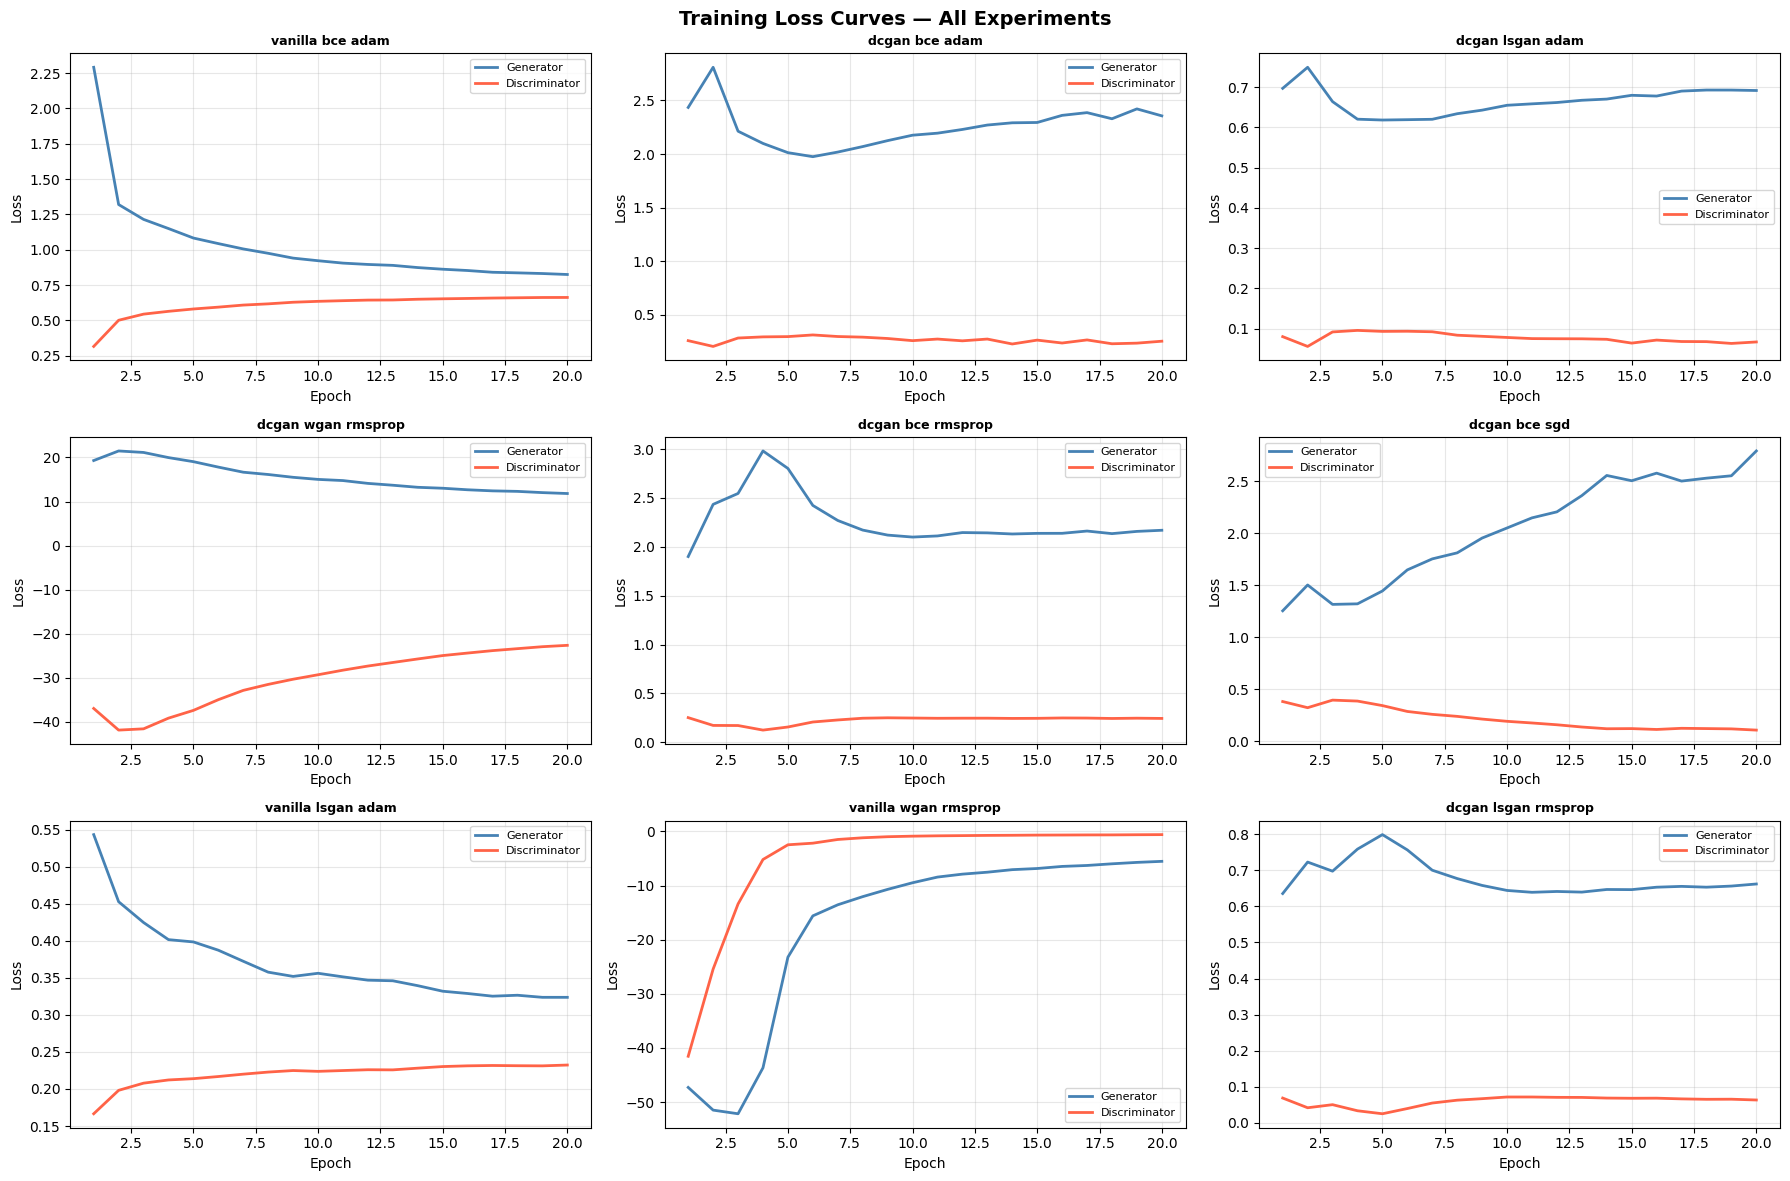

Saved: /content/loss_curves.png


In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, (key, res) in zip(axes.flatten(), RESULTS.items()):
    ep = range(1, len(res['gl']) + 1)
    ax.plot(ep, res['gl'], label='Generator',     color='steelblue', lw=2)
    ax.plot(ep, res['dl'], label='Discriminator', color='tomato',    lw=2)
    ax.set_title(key.replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Training Loss Curves — All Experiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/loss_curves.png')

## Results: Generated Images (Final Epoch)

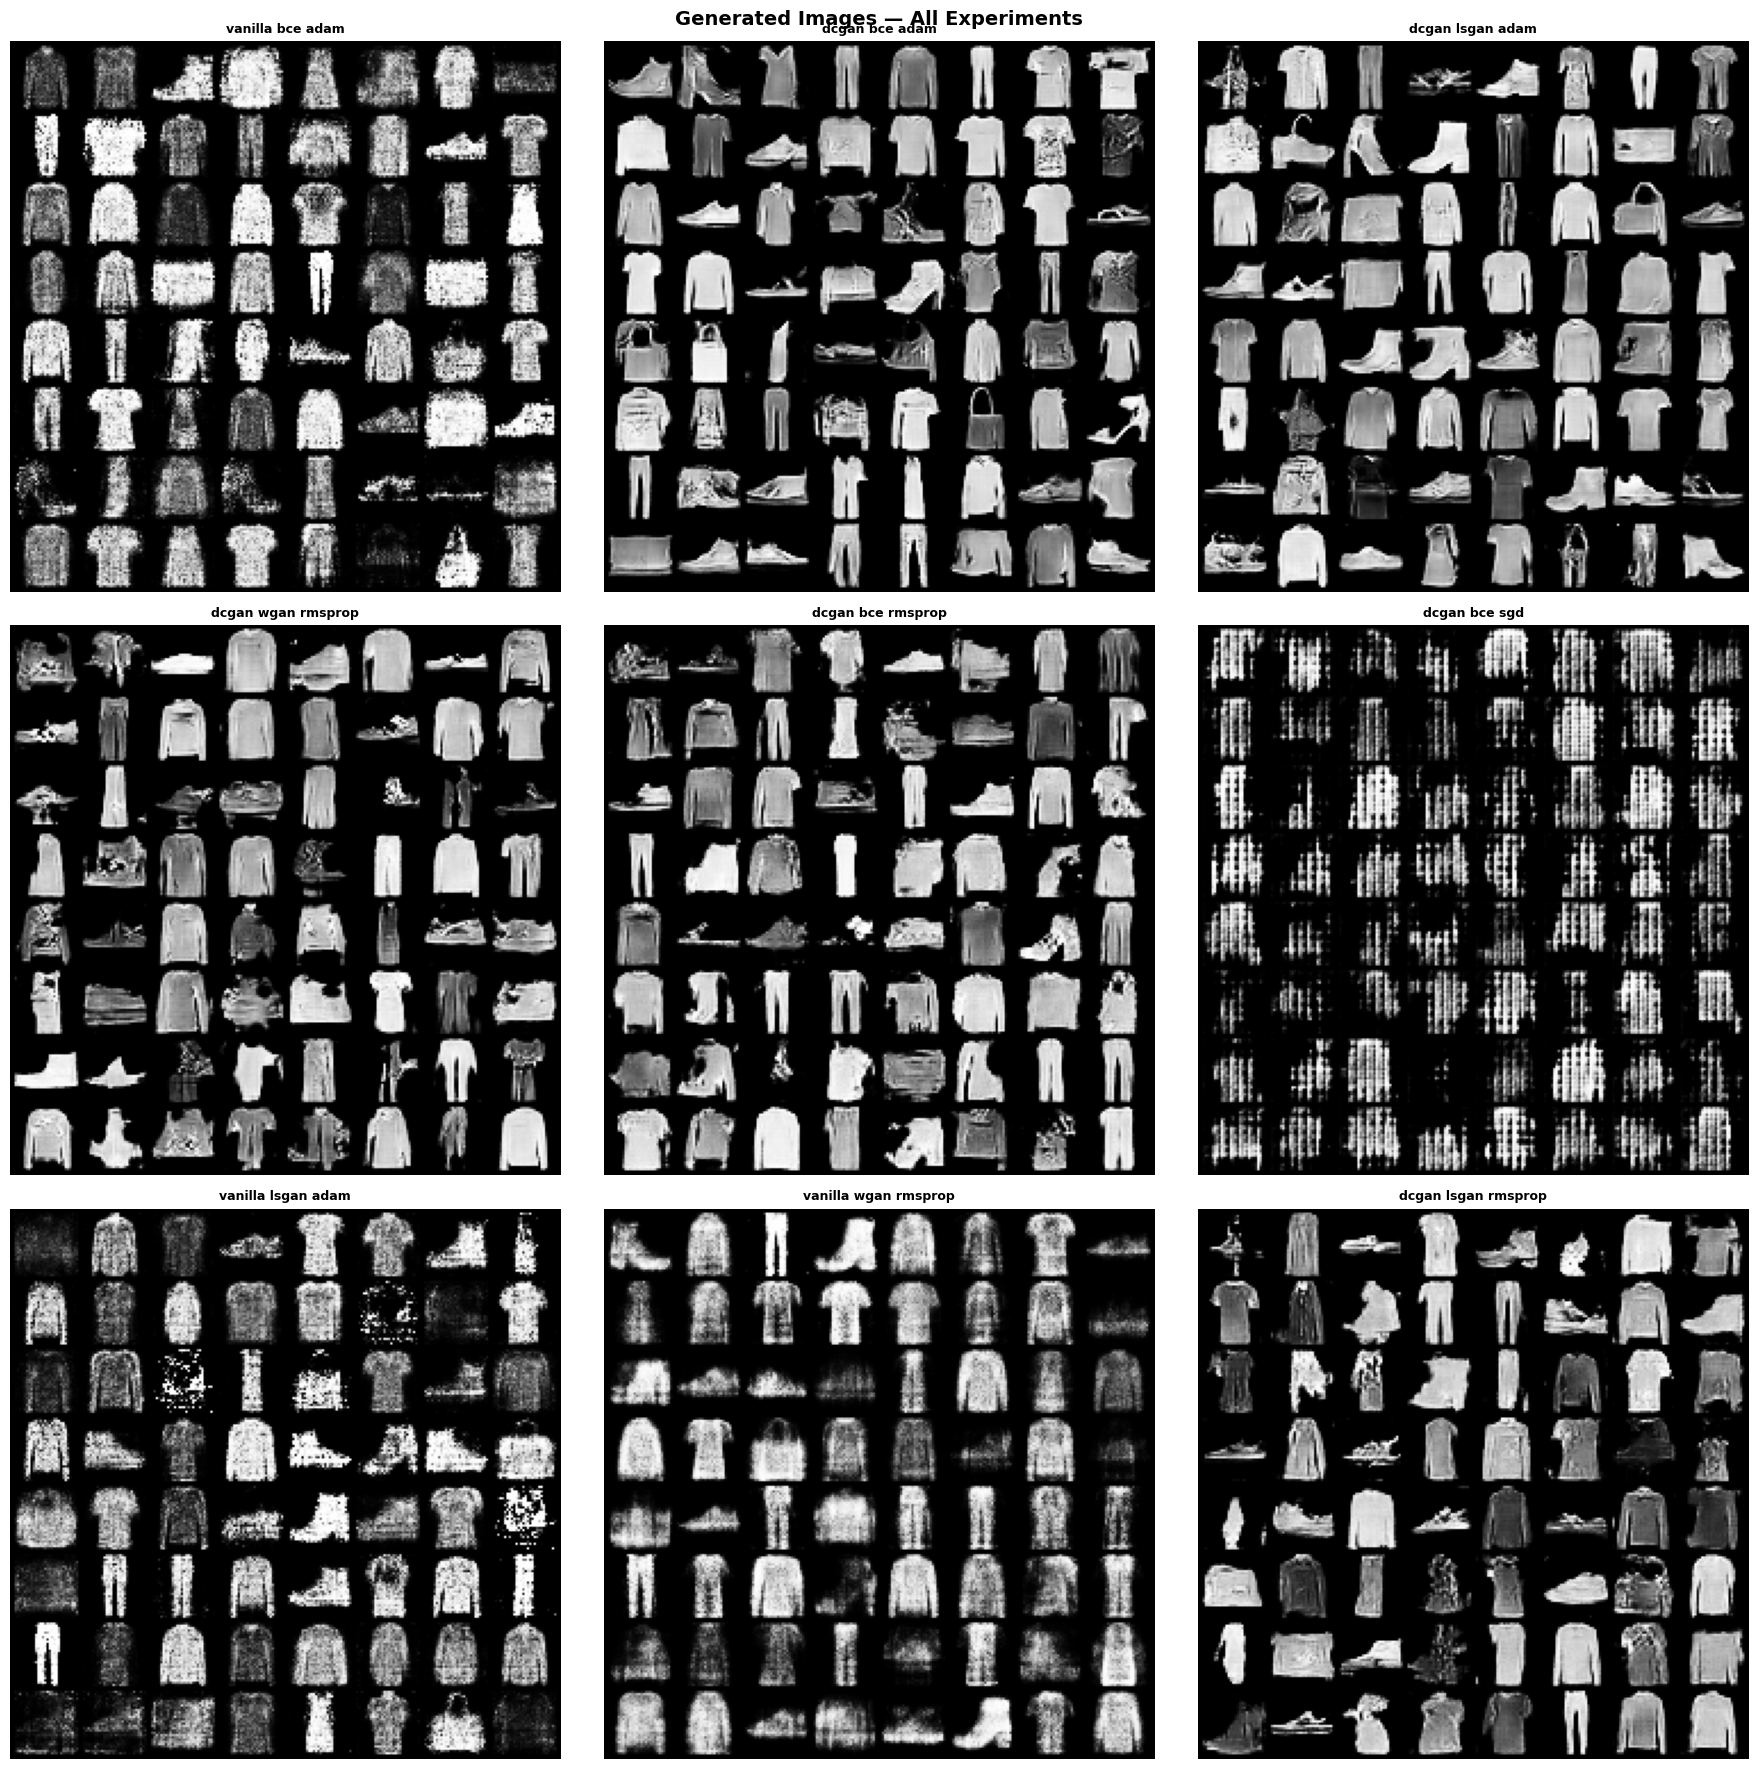

Saved: /content/generated_images.png


In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for ax, (key, res) in zip(axes.flatten(), RESULTS.items()):
    if res['grid'] is not None:
        ax.imshow(res['grid'], cmap='gray')
    ax.set_title(key.replace('_',' '), fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('Generated Images — All Experiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/generated_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/generated_images.png')

## Comparison Plots

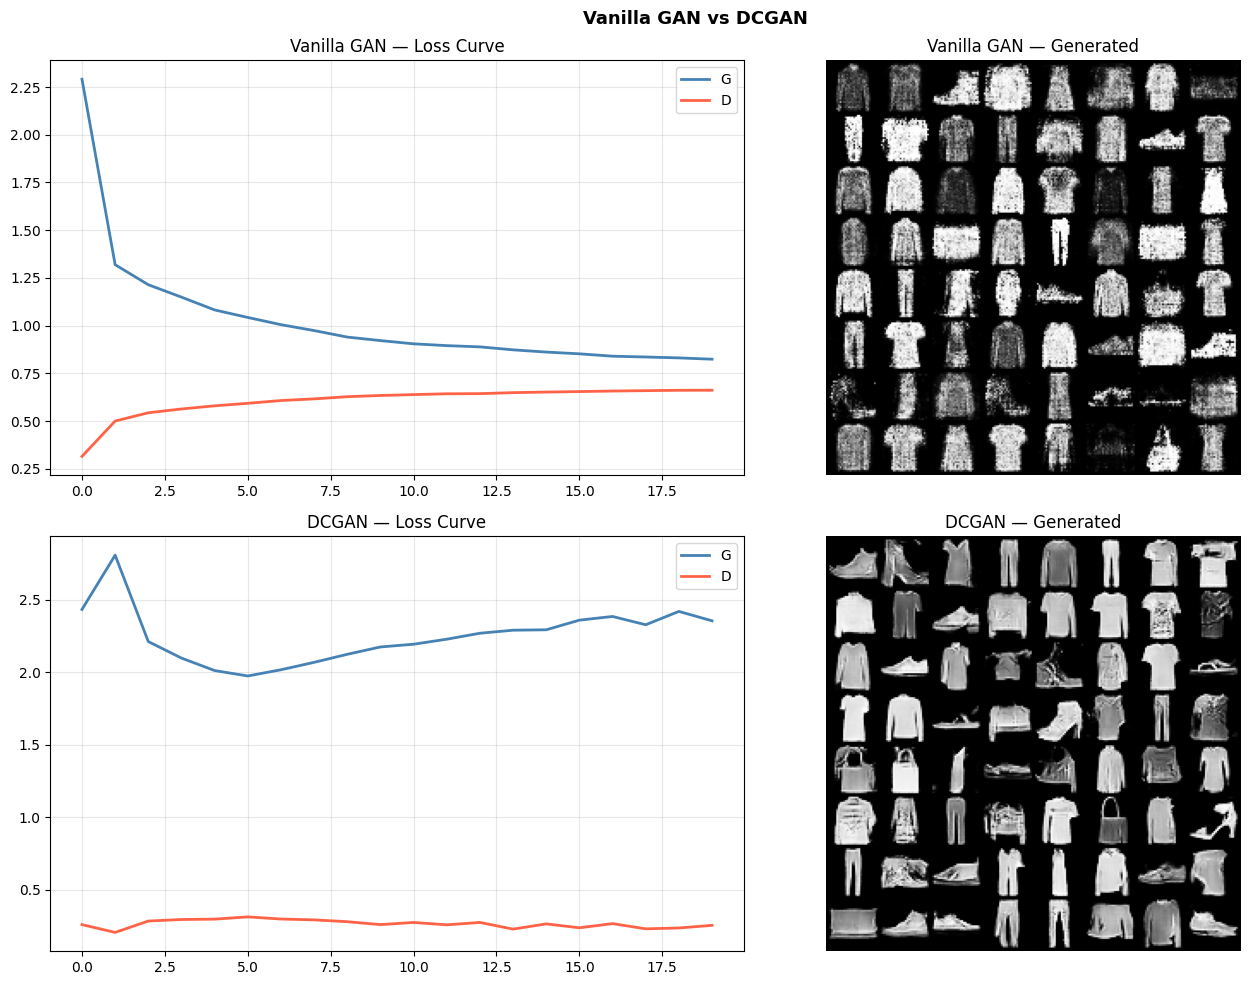

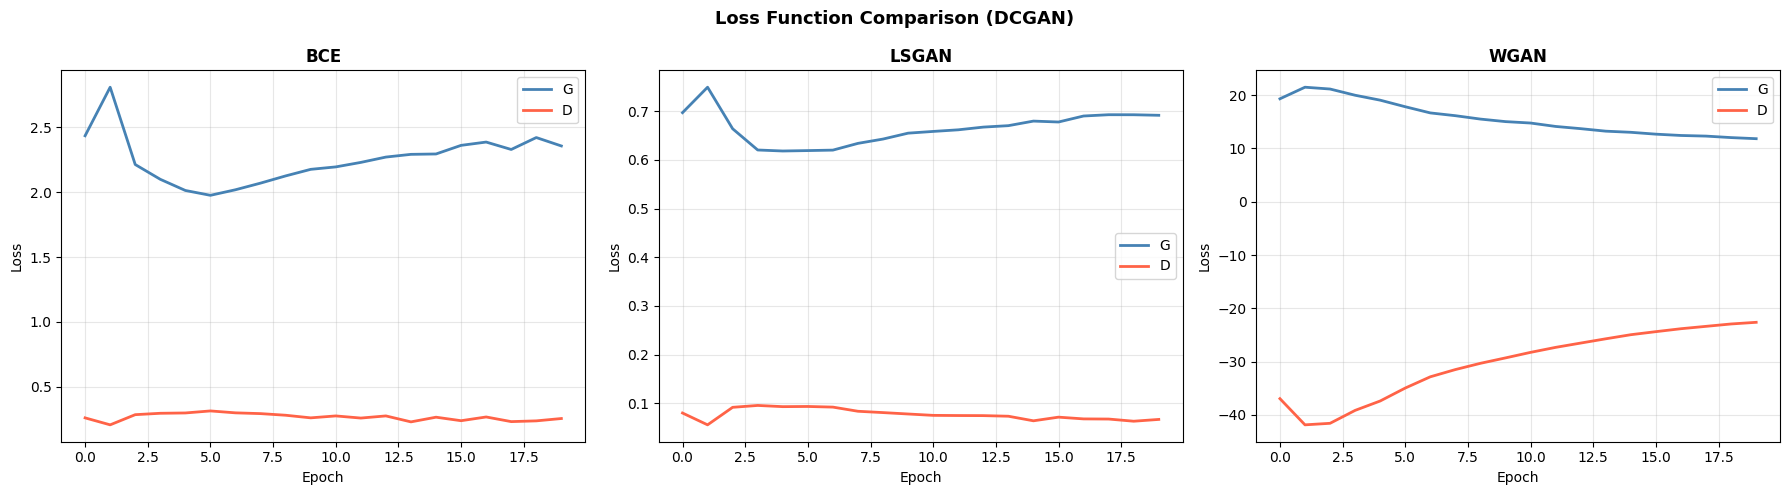

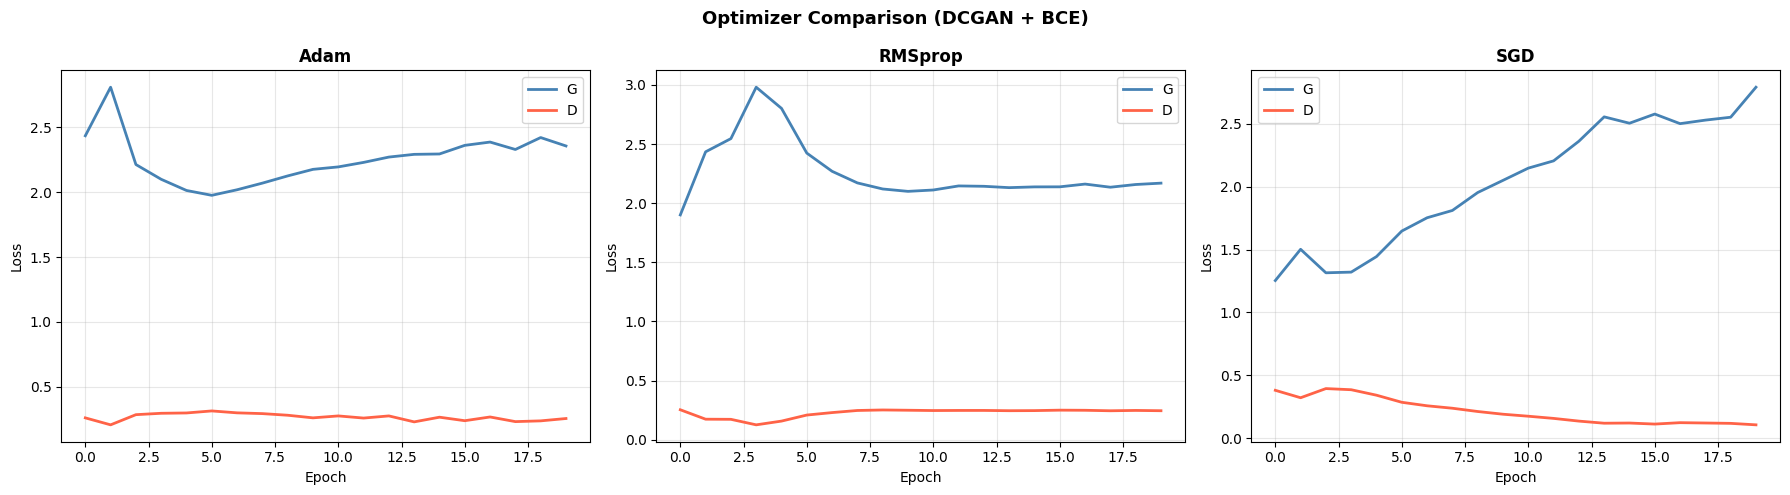

In [11]:
# ── Vanilla GAN vs DCGAN ────────────────────────────────────────────────────
pairs = [('vanilla_bce_adam','Vanilla GAN'), ('dcgan_bce_adam','DCGAN')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, (key, label) in enumerate(pairs):
    if key not in RESULTS: continue
    r = RESULTS[key]
    axes[row,0].plot(r['gl'], label='G', color='steelblue', lw=2)
    axes[row,0].plot(r['dl'], label='D', color='tomato',    lw=2)
    axes[row,0].set_title(f'{label} — Loss Curve'); axes[row,0].legend(); axes[row,0].grid(alpha=0.3)
    if r['grid'] is not None:
        axes[row,1].imshow(r['grid'], cmap='gray')
    axes[row,1].set_title(f'{label} — Generated'); axes[row,1].axis('off')
plt.suptitle('Vanilla GAN vs DCGAN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/vanilla_vs_dcgan.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Loss function comparison ─────────────────────────────────────────────────
loss_keys = [('dcgan_bce_adam','BCE'), ('dcgan_lsgan_adam','LSGAN'), ('dcgan_wgan_rmsprop','WGAN')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (key, label) in zip(axes, loss_keys):
    if key not in RESULTS: continue
    r = RESULTS[key]
    ax.plot(r['gl'], label='G', color='steelblue', lw=2)
    ax.plot(r['dl'], label='D', color='tomato',    lw=2)
    ax.set_title(f'{label}', fontweight='bold')
    ax.legend(); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.grid(alpha=0.3)
plt.suptitle('Loss Function Comparison (DCGAN)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/loss_fn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Optimizer comparison ─────────────────────────────────────────────────────
opt_keys = [('dcgan_bce_adam','Adam'), ('dcgan_bce_rmsprop','RMSprop'), ('dcgan_bce_sgd','SGD')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (key, label) in zip(axes, opt_keys):
    if key not in RESULTS: continue
    r = RESULTS[key]
    ax.plot(r['gl'], label='G', color='steelblue', lw=2)
    ax.plot(r['dl'], label='D', color='tomato',    lw=2)
    ax.set_title(f'{label}', fontweight='bold')
    ax.legend(); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.grid(alpha=0.3)
plt.suptitle('Optimizer Comparison (DCGAN + BCE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

In [12]:
import pandas as pd

rows = []
for key, r in RESULTS.items():
    arch, loss, opt = key.split('_', 2)
    rows.append(dict(
        Experiment   = key,
        Architecture = arch.upper(),
        Loss         = loss.upper(),
        Optimizer    = opt.upper(),
        G_Loss_Final = round(r['gl'][-1], 4),
        D_Loss_Final = round(r['dl'][-1], 4),
        G_Stability  = round(float(np.std(r['gl'][-10:])), 4),
        D_Stability  = round(float(np.std(r['dl'][-10:])), 4),
    ))

df = pd.DataFrame(rows)
df.to_csv('/content/experiment_summary.csv', index=False)
print(df.to_string(index=False))
print('\nSaved: /content/experiment_summary.csv')

          Experiment Architecture  Loss Optimizer  G_Loss_Final  D_Loss_Final  G_Stability  D_Stability
    vanilla_bce_adam      VANILLA   BCE      ADAM        0.8245        0.6620       0.0272       0.0078
      dcgan_bce_adam        DCGAN   BCE      ADAM        2.3557        0.2553       0.0671       0.0170
    dcgan_lsgan_adam        DCGAN LSGAN      ADAM        0.6915        0.0670       0.0126       0.0043
  dcgan_wgan_rmsprop        DCGAN  WGAN   RMSPROP       11.8158      -22.6253       0.9025       1.8205
   dcgan_bce_rmsprop        DCGAN   BCE   RMSPROP        2.1696        0.2443       0.0159       0.0016
       dcgan_bce_sgd        DCGAN   BCE       SGD        2.7912        0.1054       0.1790       0.0203
  vanilla_lsgan_adam      VANILLA LSGAN      ADAM        0.3238        0.2324       0.0101       0.0027
vanilla_wgan_rmsprop      VANILLA  WGAN   RMSPROP       -5.5197       -0.5820       0.9107       0.0671
 dcgan_lsgan_rmsprop        DCGAN LSGAN   RMSPROP        0.6618 

## Analysis & Discussion

### 1. Vanilla GAN vs DCGAN
- DCGAN uses **transposed convolutions** which preserve spatial structure — fully-connected layers treat each pixel independently, losing locality.
- **Batch Normalisation** in DCGAN stabilises gradient flow and prevents mode collapse.
- DCGAN consistently produces **sharper, more coherent** clothing textures.

### 2. Loss Function Comparison
| Loss | Pros | Cons |
|------|------|------|
| BCE | Simple, standard | Saturates → vanishing gradients when D is too strong |
| LSGAN | Smoother gradients, better convergence | Slightly slower than BCE |
| WGAN | Most stable, meaningful metric (EMD) | Needs weight clipping; slower per step |

### 3. Optimizer Comparison
| Optimizer | Behaviour |
|-----------|----------|
| Adam | Adaptive LR + momentum — best for non-stationary GAN objectives |
| RMSprop | Recommended by original WGAN paper for the critic |
| SGD | Slowest convergence; oscillatory without careful LR tuning |

### 4. Training Challenges
- **Mode Collapse** — G produces limited variety. WGAN is most resistant.
- **Vanishing Gradients** — BCE + strong D causes G to receive near-zero gradients.
- **Oscillatory Behaviour** — common with SGD; Adam reduces it significantly.

### 5. Best Configuration
> **DCGAN + LSGAN + Adam** — smooth gradients (LSGAN) + spatial coherence (DCGAN) + stable convergence (Adam).

In [13]:
print('Files saved in /content/')
for fname in sorted(os.listdir('/content/')):
    if fname.endswith(('.png','.pth','.csv')):
        size = os.path.getsize(f'/content/{fname}')
        print(f'  {fname:45s}  {size:>10,} bytes')

Files saved in /content/
  dcgan_bce_adam_G.pth                            7,700,595 bytes
  dcgan_bce_rmsprop_G.pth                         7,700,658 bytes
  dcgan_bce_sgd_G.pth                             7,700,574 bytes
  dcgan_lsgan_adam_G.pth                          7,700,637 bytes
  dcgan_lsgan_rmsprop_G.pth                       7,700,700 bytes
  dcgan_wgan_rmsprop_G.pth                        7,700,679 bytes
  experiment_summary.csv                                661 bytes
  generated_images.png                              913,527 bytes
  loss_curves.png                                   291,313 bytes
  loss_fn_comparison.png                             95,062 bytes
  optimizer_comparison.png                           99,622 bytes
  sample_images.png                                  51,555 bytes
  vanilla_bce_adam_G.pth                          5,982,301 bytes
  vanilla_lsgan_adam_G.pth                        5,982,423 bytes
  vanilla_vs_dcgan.png                             